In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df1 = pd.read_csv("01-2023.csv")
df2 = pd.read_csv("02-2023.csv")
df3 = pd.read_csv("03-2023.csv")
df4 = pd.read_csv("04-2023.csv")
df5 = pd.read_csv("05-2023.csv")
df6 = pd.read_csv("06-2023.csv")
df7 = pd.read_csv("07-2023.csv")
df8 = pd.read_csv("08-2023.csv")
df9 = pd.read_csv("09-2023.csv")
df10 = pd.read_csv("10-2023.csv")
df11 = pd.read_csv("11-2023.csv")
df12 = pd.read_csv("12-2023.csv")
df13 = pd.read_csv("01-2024.csv")
df14 = pd.read_csv("02-2024.csv")
df15 = pd.read_csv("03-2024.csv")
df16 = pd.read_csv("04-2024.csv")
df17 = pd.read_csv("05-2024.csv")
df18 = pd.read_csv("06-2024.csv")
df19 = pd.read_csv("07-2024.csv")
df20 = pd.read_csv("08-2024.csv")
df21 = pd.read_csv("09-2024.csv")
df22 = pd.read_csv("10-2024.csv")
df23 = pd.read_csv("11-2024.csv")
df24 = pd.read_csv("12-2024.csv")
df25 = pd.read_csv("01-2025.csv")
df26 = pd.read_csv("02-2025.csv")
df27 = pd.read_csv("03-2025.csv")
df28 = pd.read_csv("04-2025.csv")
df29 = pd.read_csv("05-2025.csv")
df30 = pd.read_csv("06-2025.csv")
df31 = pd.read_csv("07-2025.csv")
df32 = pd.read_csv("08-2025.csv")
df33 = pd.read_csv("09-2025.csv")
df34 = pd.read_csv("10-2025.csv")
df35 = pd.read_csv("11-2025.csv")
df36 = pd.read_csv("12-2025.csv")
df37 = pd.read_csv("01-2026.csv")

In [14]:
df = pd.concat([df1, df2, df3, df4, df5, df6, df7 ,df8, df9, df10, df11, df12,df13,df14,df15,df16,df17,df18,df19,df20,df21,df22,df23,df24,df25,df26,df27,df28,df29,df30,df31,df32,df33,df34,df35,df36,df37], ignore_index=True)

In [15]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,29440312866,2023-01-01 12:00,NaN,00:02:06,NaN,Ray Levesque
1,29444061847,2023-01-01 16:42,NaN,NaN,NaN,David Banister
2,29444240240,2023-01-01 16:48,NaN,NaN,NaN,David Banister
3,29444260139,2023-01-01 16:54,NaN,NaN,NaN,David Banister
4,29444240665,2023-01-01 16:57,NaN,NaN,NaN,David Banister
...,...,...,...,...,...,...
409724,102832693381,2026-01-31 17:31,Outbound,00:00:02,NaN,Abhi C
409725,102857403185,2026-01-31 18:12,Inbound,00:08:03,NaN,Sam Steindorf
409726,102843319175,2026-01-31 20:15,Outbound,00:00:17,NaN,David Valdez
409727,102918239158,2026-01-31 20:16,Outbound,00:29:34,NaN,David Valdez


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409729 entries, 0 to 409728
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Record ID             409729 non-null  int64  
 1   Activity date         409729 non-null  object 
 2   Call direction        252550 non-null  object 
 3   Call duration         378021 non-null  object 
 4   hs_call_outcome       0 non-null       float64
 5   Activity assigned to  396977 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 18.8+ MB


In [17]:
df1 = df.drop(columns = ['hs_call_outcome', 'Record ID'])

In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409729 entries, 0 to 409728
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Activity date         409729 non-null  object
 1   Call direction        252550 non-null  object
 2   Call duration         378021 non-null  object
 3   Activity assigned to  396977 non-null  object
dtypes: object(4)
memory usage: 12.5+ MB


In [19]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors = "coerce"
)

In [20]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409729 entries, 0 to 409728
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Activity date         409729 non-null  datetime64[ns]
 1   Call direction        252550 non-null  object        
 2   Call duration         378021 non-null  object        
 3   Activity assigned to  396977 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 12.5+ MB


# Call Count per day

In [21]:
df2 = df1.copy()

In [22]:
df2['date'] = df2['Activity date'].dt.date

In [23]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque,2023-01-01
1,2023-01-01 16:42:00,NaN,NaN,David Banister,2023-01-01
2,2023-01-01 16:48:00,NaN,NaN,David Banister,2023-01-01
3,2023-01-01 16:54:00,NaN,NaN,David Banister,2023-01-01
4,2023-01-01 16:57:00,NaN,NaN,David Banister,2023-01-01


In [24]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns = {'Activity date': 'date'})
)

In [25]:
daily_calls

,date,call_count
0,2023-01-01,15
1,2023-01-02,34
2,2023-01-03,231
3,2023-01-04,220
4,2023-01-05,146
...,...,...
1119,2026-01-27,895
1120,2026-01-28,930
1121,2026-01-29,872
1122,2026-01-30,930


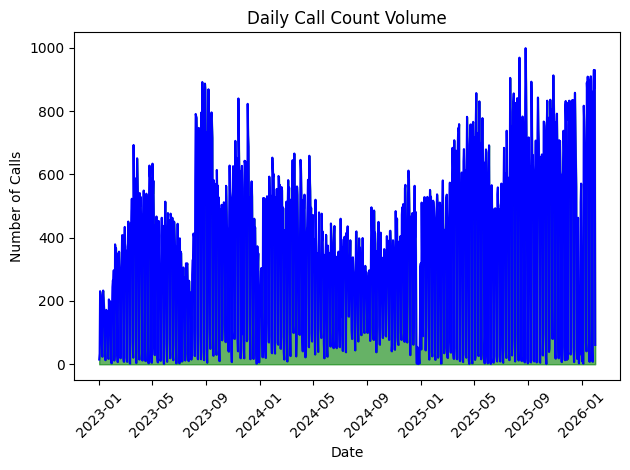

In [26]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color = 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'green', alpha = 0.6)

plt.title('Daily Call Count Volume')
plt.xlabel('Date')
plt.ylabel('Number of Calls')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque
1,2023-01-01 16:42:00,NaN,NaN,David Banister
2,2023-01-01 16:48:00,NaN,NaN,David Banister
3,2023-01-01 16:54:00,NaN,NaN,David Banister
4,2023-01-01 16:57:00,NaN,NaN,David Banister


# Count of Call in Weekdays

In [28]:
df1['day'] = df1['Activity date'].dt.day_name()

In [29]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque,Sunday
1,2023-01-01 16:42:00,NaN,NaN,David Banister,Sunday
2,2023-01-01 16:48:00,NaN,NaN,David Banister,Sunday
3,2023-01-01 16:54:00,NaN,NaN,David Banister,Sunday
4,2023-01-01 16:57:00,NaN,NaN,David Banister,Sunday


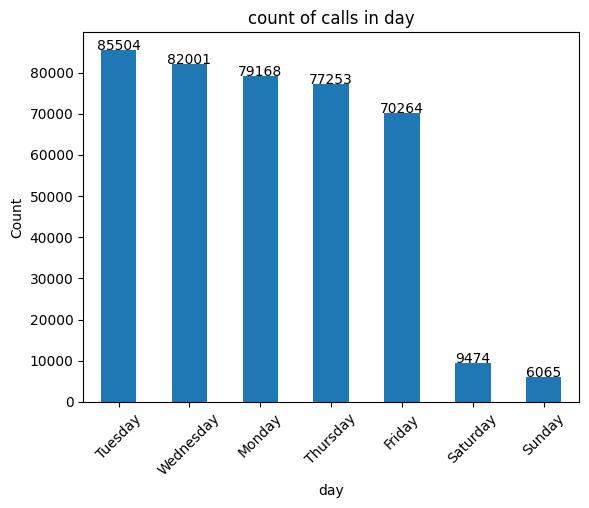

In [30]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

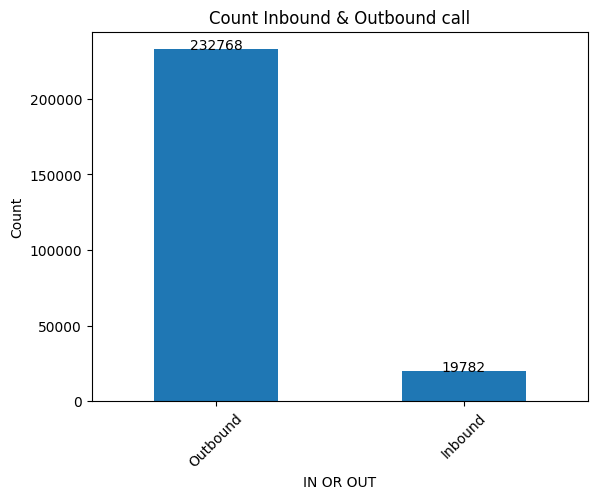

In [31]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [32]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

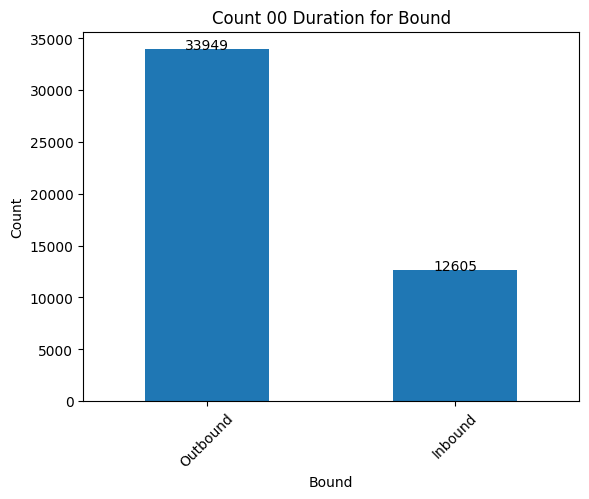

In [33]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [34]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
70,2023-01-03 11:28:00,Outbound,NaN,Keith Antonio,Tuesday
71,2023-01-03 11:29:00,Outbound,NaN,Keith Antonio,Tuesday
72,2023-01-03 11:31:00,Outbound,NaN,Keith Antonio,Tuesday
73,2023-01-03 11:33:00,Outbound,NaN,Keith Antonio,Tuesday
74,2023-01-03 11:35:00,Outbound,NaN,Keith Antonio,Tuesday
...,...,...,...,...,...
379176,2025-12-02 16:59:00,Outbound,NaN,Oliver Martin,Tuesday
379177,2025-12-02 17:00:00,Outbound,NaN,Cameron Dudley,Tuesday
379178,2025-12-02 17:00:00,Outbound,NaN,Oliver Martin,Tuesday
379267,2025-12-02 18:30:00,Outbound,NaN,Oliver Martin,Tuesday


In [35]:
df4 = df1.copy()

In [36]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque,Sunday
1,2023-01-01 16:42:00,NaN,NaN,David Banister,Sunday
2,2023-01-01 16:48:00,NaN,NaN,David Banister,Sunday
3,2023-01-01 16:54:00,NaN,NaN,David Banister,Sunday
4,2023-01-01 16:57:00,NaN,NaN,David Banister,Sunday


In [37]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [38]:
(df4['Call duration'] == 0).sum()

46554

In [39]:
df4['Call duration'].isnull().sum()

31708

In [40]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [41]:
df4 = df4.dropna(subset = ['Call direction'])

In [42]:
df4['Call duration'].isnull().sum()

0

In [43]:
df4['Call direction'].isnull().sum()

0

In [44]:
(df4['Call duration'] == 0).sum()

49439

# Working Call Assigner

In [45]:
df1['Activity assigned to'].nunique()

83

In [46]:
df1['Activity assigned to'].unique()

array(['Ray Levesque', 'David Banister', 'Travis Fleming', 'Terry Kim',
       'Cameron Dudley', 'Dioni Canega', nan, 'Paol Guzman',
       'Keith Antonio', 'Tommie Walker', 'Vladimir Suparto',
       'Jinky Rance', 'Karen Parker', 'Chrystel Manabat',
       'Adonis Baybayan', 'Kent Encarnacion', 'Henry Good',
       'Bill Goodwin', 'Branden Newman', 'John Meersma', 'Jacob Hess',
       'Adrian Tran', 'Justin Schmidt', 'David Valdez', 'Andy Ramirez',
       'Stephen Tarr', 'Ra’Saan Daniels', 'Demmie Rose Tamonan',
       'Daniel Uli', 'Justin Bellware', 'Jannica Nikka Antipuna',
       'Benjamin Sklivas', 'Sal Berdayi', 'Robin Stoehr', 'Louis Maciel',
       'Oliver Martin', 'True Ellis', 'Colby Rintharamy', 'Pete Clements',
       'Sam Steindorf', 'Garrett Evans', 'Juan Calo', 'Brittany Digiulio',
       'Tanner Schunk', 'Tyler Jury', 'Boston Hoppman', 'Kevin Vachhani',
       'Spenser Szakacs', 'Jesse Boyd', 'Nick Rothacher', 'Noah Burton',
       'Tyler Smith', 'Christian Banks', 'B

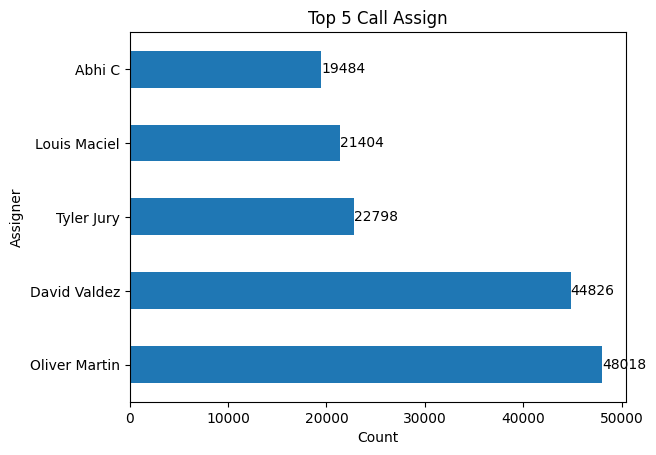

In [47]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# MAX CALL DURATION

In [48]:
df4['Call duration'].max()

163.6

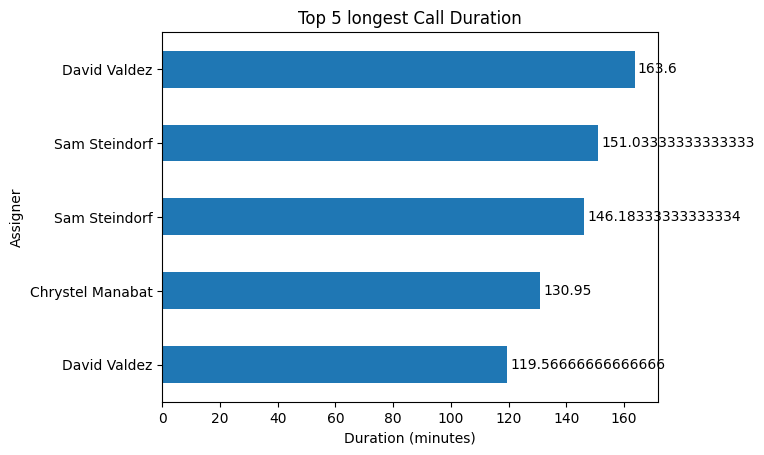

In [49]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Week days Call Volume

In [50]:
df3=df1.copy()

In [51]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [52]:
df3['day'].unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'],
      dtype=object)

In [53]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

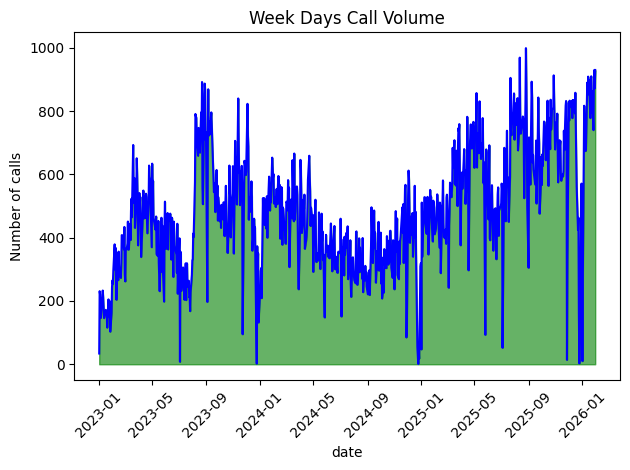

In [54]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [55]:
df5 = df4.copy()

In [56]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [57]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
802,2023-01-07 10:01:00,Outbound,1.450000,Ray Levesque,Saturday
818,2023-01-07 11:54:00,Outbound,0.666667,Ray Levesque,Saturday
823,2023-01-07 12:16:00,Outbound,1.683333,Ray Levesque,Saturday
824,2023-01-07 12:40:00,Outbound,25.483333,Ray Levesque,Saturday
842,2023-01-07 13:57:00,Outbound,7.433333,Ray Levesque,Saturday


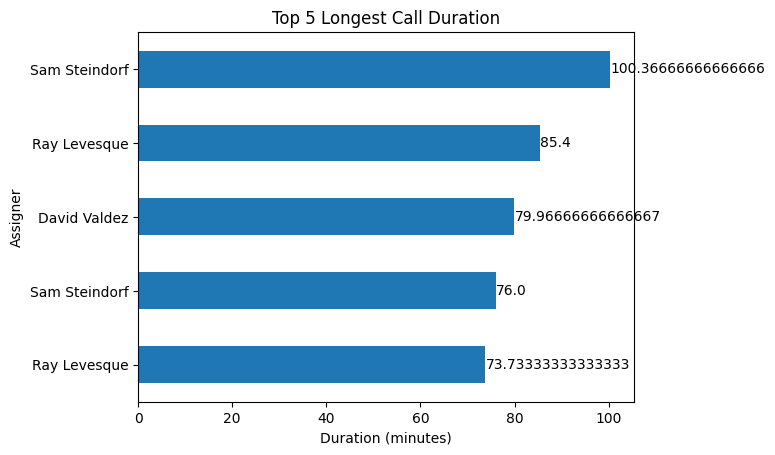

In [58]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

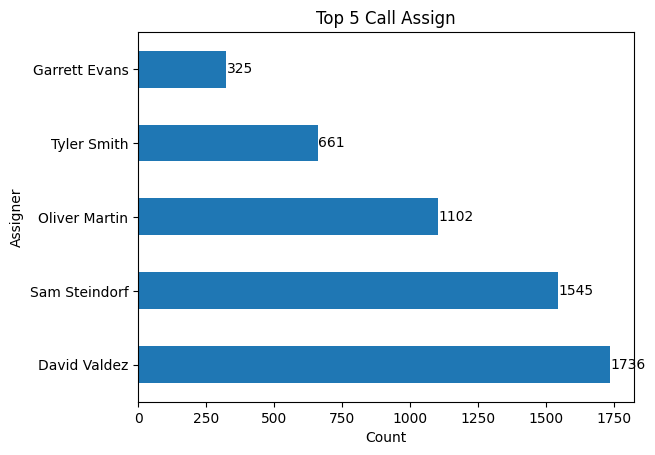

In [59]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Montly Call Count

In [60]:
df6 = df3.copy()

In [61]:
df6['month'] = df6['Activity date'].dt.month_name()

In [62]:
df6.head()

,Activity date,Call direction,Call duration,Activity assigned to,day,month
15,2023-01-02 10:01:00,NaN,00:31:50,Travis Fleming,Monday,January
16,2023-01-02 10:20:00,NaN,00:04:20,Ray Levesque,Monday,January
17,2023-01-02 13:03:00,NaN,NaN,David Banister,Monday,January
18,2023-01-02 13:19:00,NaN,NaN,David Banister,Monday,January
19,2023-01-02 13:23:00,NaN,NaN,David Banister,Monday,January


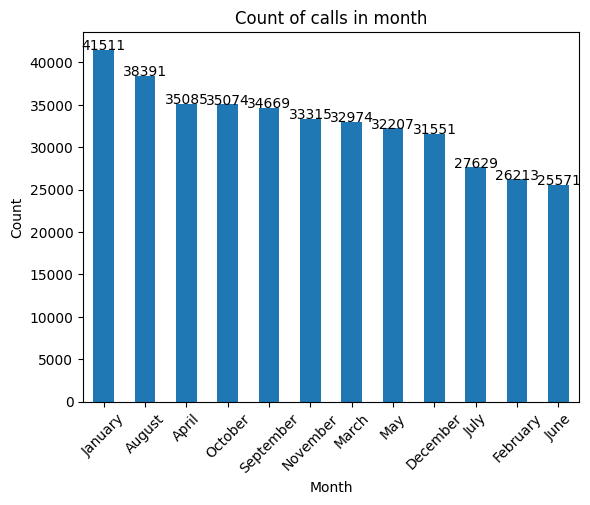

In [63]:
month_counts = df6["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls in month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Avergae Call Duration

In [64]:
df4["Call duration"].mean()

2.00270533887679

In [65]:
df4["Call duration"].median()

0.13333333333333333

# WITHOUT CALL ASSIGNER CALLS

In [66]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

In [67]:
no_assigner_calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12142 entries, 67 to 409667
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         12142 non-null  datetime64[ns]
 1   Call direction        11835 non-null  object        
 2   Call duration         12138 non-null  object        
 3   Activity assigned to  0 non-null      object        
 4   day                   12142 non-null  object        
 5   month                 12142 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 664.0+ KB


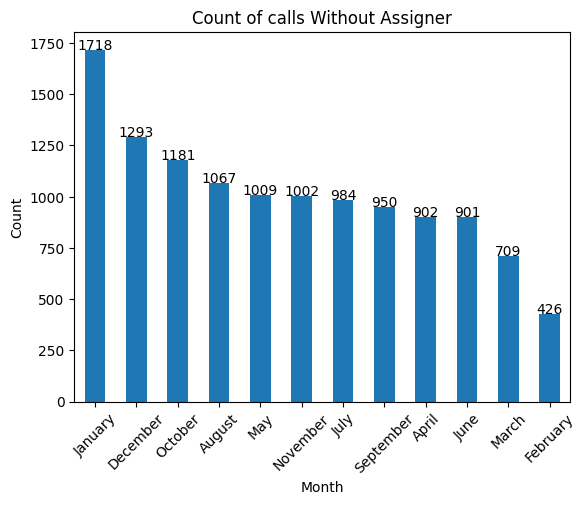

In [68]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 PEAK CALL DATE

In [69]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [70]:
top5 = daily_calls.sort_values(ascending=False).head(5)

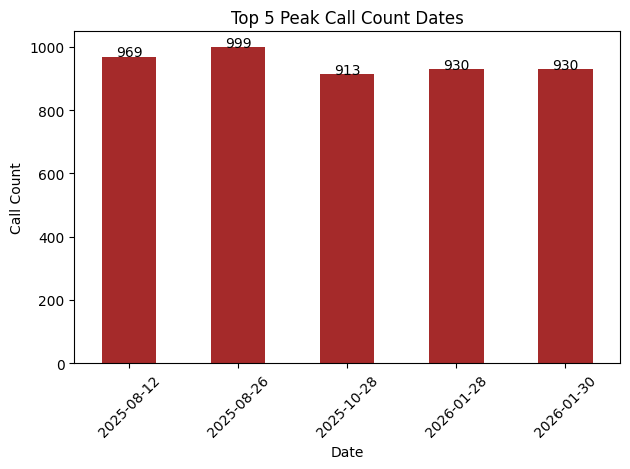

In [71]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count Dates")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()